Hotel Booking Cancellation Prediction

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
#loading data set
data = pd.read_csv("/content/hotel_bookings.csv")
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,07-01-2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,07-01-2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,07-02-2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,07-02-2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,07-03-2015


In [3]:
#Basic EDA
print("Shape:", data.shape)
print("\nMissing Values:\n", data.isnull().sum())

Shape: (119390, 32)

Missing Values:
 hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent              

In [4]:
#Data Cleaning
# Drop unnecessary column
if 'company' in data.columns:
    data = data.drop("company", axis=1)

# Fill missing values
data["agent"] = data["agent"].fillna(data["agent"].median())
data["country"] = data["country"].fillna(data["country"].mode()[0])
data["children"] = data["children"].fillna(data["children"].median())

In [5]:
#Encoding Categorical Variables
categorical_cols = data.select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [6]:
X = data.drop(["is_canceled", "reservation_status", "reservation_status_date"], axis=1)
y = data["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [7]:
#Model Training Function
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"---> {name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    print("-"*50)

    return acc

In [8]:
#Training data acorss algorithms
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Ridge Classifier": RidgeClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=300),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300),
    "Bagging": BaggingClassifier(n_estimators=200),
    "AdaBoost": AdaBoostClassifier(n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200)
}

results = []
for name, model in models.items():
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    if name in ["Logistic Regression", "Ridge Classifier", "KNN", "SVM (RBF)", "Naive Bayes"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])
    print("----", name, "----")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    print("-" * 60)

---- Logistic Regression ----
Accuracy: 0.7953206577882012
              precision    recall  f1-score   support

           0       0.79      0.92      0.85     22478
           1       0.81      0.59      0.68     13339

    accuracy                           0.80     35817
   macro avg       0.80      0.75      0.77     35817
weighted avg       0.80      0.80      0.79     35817

------------------------------------------------------------
---- Ridge Classifier ----
Accuracy: 0.7766144568221794
              precision    recall  f1-score   support

           0       0.76      0.95      0.84     22478
           1       0.84      0.49      0.62     13339

    accuracy                           0.78     35817
   macro avg       0.80      0.72      0.73     35817
weighted avg       0.79      0.78      0.76     35817

------------------------------------------------------------
---- Decision Tree ----
Accuracy: 0.8564648072144513
              precision    recall  f1-score   support

 

In [9]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy
3,Random Forest,0.895050
5,Bagging,0.892705
4,Extra Trees,0.890192
7,Gradient Boosting,0.862160
2,Decision Tree,0.856465
6,AdaBoost,0.827763
0,Logistic Regression,0.795321
1,Ridge Classifier,0.776614


In [19]:
results_df = (
    pd.DataFrame(results, columns=["Model", "Accuracy"])
      .sort_values(by="Accuracy", ascending=False)
      .reset_index(drop=True)
)


results_df


,Model,Accuracy
0,Random Forest,0.895050
1,Bagging,0.892705
2,Extra Trees,0.890192
3,Gradient Boosting,0.862160
4,Decision Tree,0.856465
5,AdaBoost,0.827763
6,Logistic Regression,0.795321
7,Ridge Classifier,0.776614


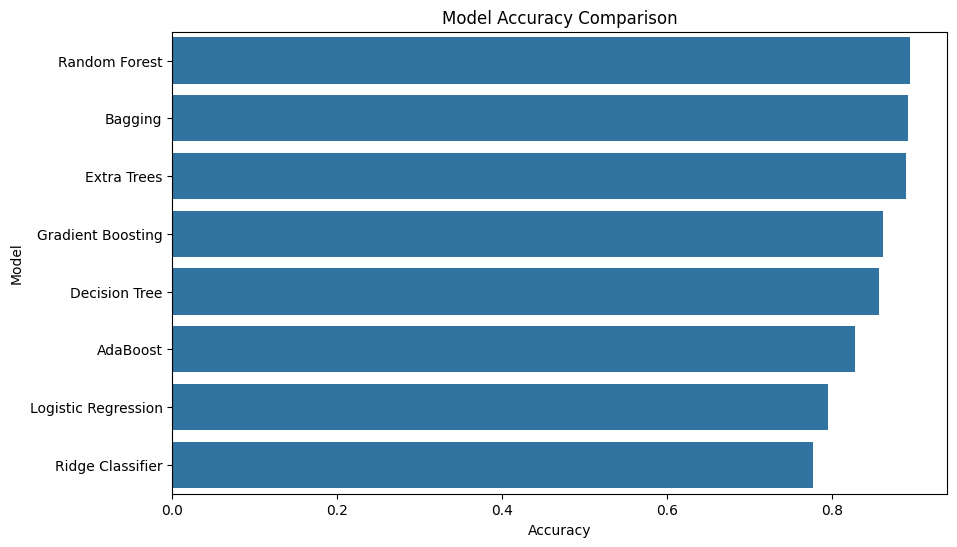

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(x="Accuracy", y="Model", data=results_df)
plt.title("Model Accuracy Comparison")
plt.show()

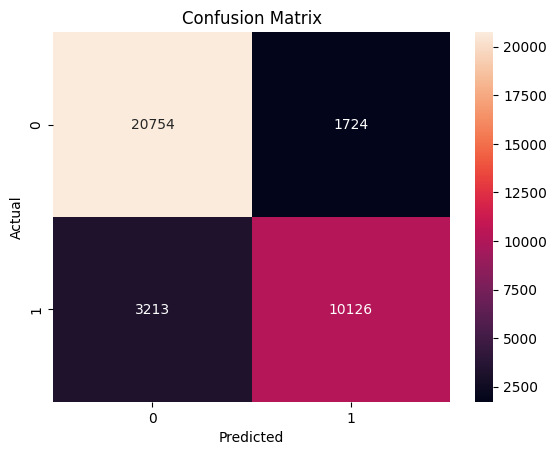

In [13]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

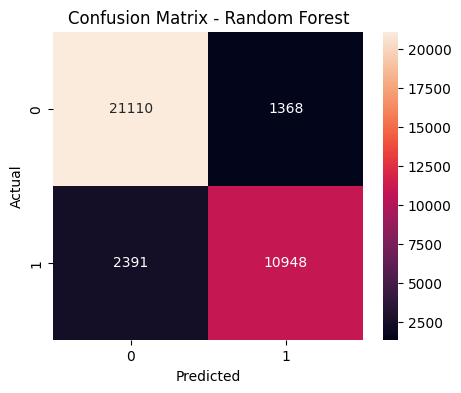

In [15]:
y_pred = best_model.predict(X_test)

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

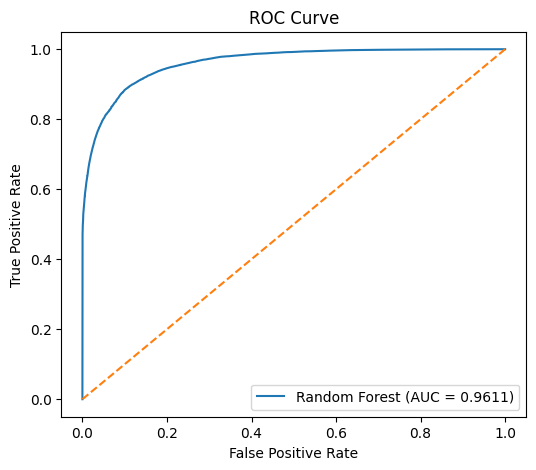

In [17]:
if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test)[:, 1]
else:
    y_prob = best_model.decision_function(X_test)

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {auc_score:.4f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [23]:
best_accuracy = results_df.iloc[0]["Accuracy"]
print("\nFinal Selected Model: Random Forest")
print(f"Final Accuracy: {results_df.iloc[0]["Accuracy"]:.5f}")
print(f"ROC-AUC Score: {auc_score:.4f}")


Final Selected Model: Random Forest
Final Accuracy: 0.89505
ROC-AUC Score: 0.9611
